# Star Classification Neural Network With Pytorch

## Introduction:

Whenever I hear any stories about stars far far away from earth, Im talking millions of light years away not possibly seen visually through any telescope, I always wonder: <center> *"How on earth (pun intended) do they find out what typa star it is from this far away?!"* </center>  
And to satisfy this curiousity, I did a little google search and found out that every star has its own life cycle, ranging from a few million to trillions of years, and its properties change as it ages. And by measuring these properties, we can deduce the type of star.

But I'm not satisfied until I do it myself. So in this notebook I'll be writing a model that classifies a star's type based on it's features. (And also serve as a good practice for Pytorch)

## Dataset

The dataset consists of 6 collumns.
- The Temperature of the star
- The Luminosity of the star
- It's Radius
- It's Absolute Magnitude
- It's General Color of Spectrum
- The Spectral Class

Everything should be obvious, however the Spectral Class might be news.  
An asteroid spectral type is assigned to asteroids based on their reflectance spectrum (its effectiveness in reflecting radiant energy)

In [1]:
import os
from pathlib import Path

iskaggle = os.environ.get("KAGGLE_KERNEL_RUN_TYPE", '')
if iskaggle: path = Path('../input/star-type-classification')
else:
    path = Path('data')

#### Here's a quick look at the data:

In [2]:
import pandas as pd

data = pd.read_csv(path/'Stars.csv')
data

,temperature,luminosity,radius,magnitude,color,class,label
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Blue,O,5
236,30839,834042.000000,1194.0000,-10.63,Blue,O,5
237,8829,537493.000000,1423.0000,-10.73,White,A,5
238,9235,404940.000000,1112.0000,-11.23,White,A,5


#### Sampling the dataset is cool and all, but we wanna see some more important information

In [3]:
data.describe()

,temperature,luminosity,radius,magnitude,label
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


#### Quick Overview
Some values differ alot, and this outliers are not very good for writing a model that can generalize to new data.  
The smallest value for luminosity is as low as 0.00008 (That's 4 zeros!!) whereas the largest gets up to ~850,000  
Now come's a dillemma: <center>*"Should I normalize the data, or preserve their differences?"*</center>  
Best way to know, is to check if these overly small/huge values are truly outliers and must be normalized.

<Axes: >

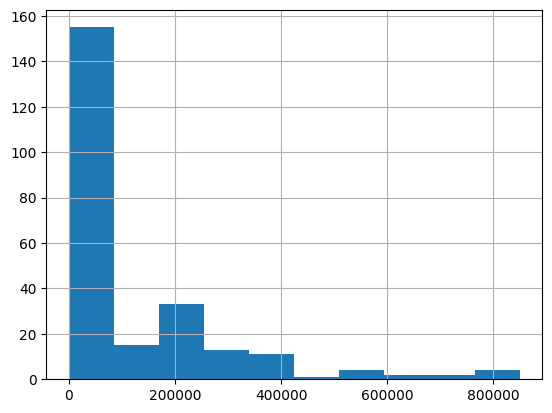

In [4]:
data['luminosity'].hist()

Almost half of the dataset has it's luminosity in the decimals!! With the rest being in the hundreds of thousands.  
Alright, we'll have to normalize this. I'll use Z-Score which will transform the dataset into having a mean of 0 and a standard deviation of 1.
$$
z = \frac{x - \mu}{\sigma}
$$
It's very simple, you subtract the original value by the mean of the column, and divide that by the standard deviation.

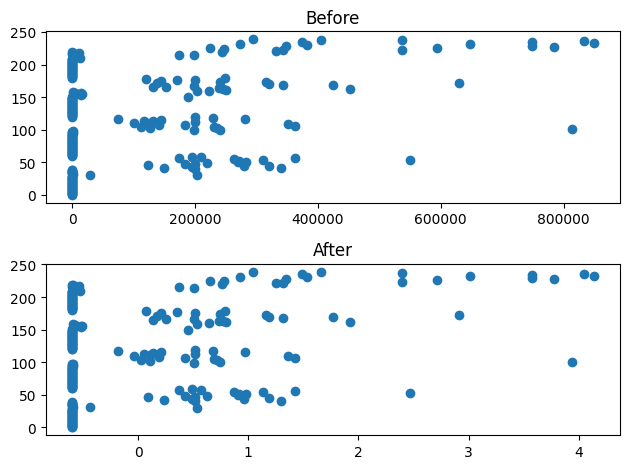

In [5]:
import torch
import matplotlib.pyplot as plt

def z_score(x): return (x - torch.mean(x)) / torch.std(x)

normalized_luminosity = z_score(torch.tensor(data.luminosity))



plt.subplot(2, 1, 1)
plt.scatter(data['luminosity'].to_numpy(), range(240))
plt.title('Before')
plt.subplot(2, 1, 2)
plt.scatter(normalized_luminosity.numpy(), range(240))
plt.title('After')
plt.tight_layout()
plt.show()

#### From hundreds of thousand's to single digits, while still preserving the data's structure! Perfect!

---

#### Preparation

Now ill convert the dataframe into a tensor and prepare it to be chucked into a neural network.  
This dataset already is very well-put together. There are no nil values, however there is a need for dummy columns.

So let's make this quick, and get it over with!

First up is defining the dependant and independant variables as tensors

In [6]:
import numpy as np

t_dep = torch.tensor(data['label'])
t_indep = torch.tensor(data.drop(columns=['label']).astype(np.float32).values, dtype=torch.float)

ValueError: could not convert string to float: 'Red'

Oh golly jargon!! Damn, what went wrong?!
Let's see here..

```
ValueError: could not convert string to float: 'Red'
```

We tried to convert a word into a number!  
Ah.. almost forgot math needs numbers..

### Dummy Columns

In [7]:
data['color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'yellowish',
       'Yellowish', 'Orange-Red', 'Blue-White'], dtype=object)

As we can see, the color column has 17 possible colors a star can be.  
However, since we can only accept numbers, an easy fix is using **Dummy Columns**  

Ill give you an example, say we had data for a group of people. One of the columns is "Gender" where each person could have the value "Female" or "Male". To turn these into numbers, we'll create 2 new columns:
- "Female?"
- "Male?"

Say you have bob, a professional male specializing in being a man. His female column would be "0" for false, and his male column would be "1" for true.  
Boom!! Problem solved.

So to apply this here, we'll just make 17 columns for every color of star.

In [8]:
data = pd.get_dummies(data, columns=['color', 'class'])
data[["color_Red", "color_Blue White", "color_White", "color_Yellowish White", "color_Blue white", "color_Pale yellow orange", "color_Blue", "color_Blue-white", "color_Whitish", "color_yellow-white", "color_Orange", "color_White-Yellow", "color_white", "color_yellowish", "color_Yellowish", "color_Orange-Red", "color_Blue-White"]].sample(5)

,color_Red,color_Blue White,color_White,color_Yellowish White,color_Blue white,color_Pale yellow orange,color_Blue,color_Blue-white,color_Whitish,color_yellow-white,color_Orange,color_White-Yellow,color_white,color_yellowish,color_Yellowish,color_Orange-Red,color_Blue-White
157,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
198,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
92,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
59,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
115,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Phew, let's try this again now.

In [9]:
import numpy as np

t_dep = torch.tensor(data['label'])
t_indep = torch.tensor(data.drop(columns=['label']).astype(np.float32).values, dtype=torch.float)

No errors! Eureka!